In [41]:
import tensorflow as tf
import sys

print(f"TensorFlow version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"SUCCESS: GPU Detected: {gpu_devices}")
else:
    print("WARNING: No GPU detected.")

TensorFlow version: 2.15.0
SUCCESS: GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [42]:
import numpy as np
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import pandas as pd

# Define Custom Metric (REQUIRED to load the model)
@tf.keras.utils.register_keras_serializable()
class MultiLabelF1(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision_m = tf.keras.metrics.Precision(thresholds=threshold)
        self.recall_m = tf.keras.metrics.Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision_m.update_state(y_true, y_pred, sample_weight)
        self.recall_m.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision_m.result()
        r = self.recall_m.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision_m.reset_states()
        self.recall_m.reset_states()

# Load the Saved Model
print("Loading model...")
model = tf.keras.models.load_model('saved_model/final_crnn_model.keras', custom_objects={'MultiLabelF1': MultiLabelF1})
print("Model loaded successfully!")

Loading model...


Model loaded successfully!


In [65]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import librosa

EMOTIONS = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness',
            'power', 'joyful_activation', 'tension', 'sadness']

def create_mel_spectrogram_segments(audio_path, segment_length=5, hop_length=2.5, target_shape=(128, 216)):
    """Preprocess audio into segments with global normalization."""
    try:
        y, sr = librosa.load(audio_path, duration=60)
        segments = []
        segment_samples = int(segment_length * sr)
        hop_samples = int(hop_length * sr)

        for start in range(0, len(y) - segment_samples + 1, hop_samples):
            segment = y[start:start+segment_samples]
            mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
            mel_db = librosa.power_to_db(mel, ref=1.0) 

            # Global Normalization (-80dB to 0dB)
            mel_db = np.clip(mel_db, -80, 0)
            mel_db = (mel_db + 80) / 80

            if mel_db.shape[1] < target_shape[1]:
                mel_db = np.pad(mel_db, ((0, 0), (0, target_shape[1] - mel_db.shape[1])))
            else:
                mel_db = mel_db[:, :target_shape[1]]

            segments.append(mel_db)
        return segments
    except Exception as e:
        print(f"Error processing audio: {e}")
        return None

def predict_and_plot(audio_path, song_title="Song Prediction", ground_truth=None):
    print(f"🎵 Analyzing: {song_title}...")

    # Preprocess
    segments = create_mel_spectrogram_segments(audio_path)
    if not segments: return None

    # Predict
    X = np.array(segments)[..., np.newaxis]
    preds = model.predict(X, verbose=0)
    avg_pred = np.mean(preds, axis=0)

    sns.set_theme(style="white", context="talk") 
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Create a DataFrame for easier plotting
    plot_data = pd.DataFrame({
        'Emotion': EMOTIONS,
        'Score': avg_pred,
        'Type': ['Prediction'] * len(EMOTIONS)
    })

    # If Ground Truth is provided, add it to the plot data for comparison
    if ground_truth:
        gt_values = [ground_truth.get(emo, 0) for emo in EMOTIONS]
        gt_df = pd.DataFrame({
            'Emotion': EMOTIONS,
            'Score': gt_values,
            'Type': ['Ground Truth'] * len(EMOTIONS)
        })
        plot_data = pd.concat([plot_data, gt_df])
        
        colors = ["#364F6B", "#3FC1C9"] 
        bar_plot = sns.barplot(data=plot_data, x='Emotion', y='Score', hue='Type', 
                               palette=colors, edgecolor=".2", ax=ax)
    else:
        # Single prediction plot if no ground truth
        colors = sns.color_palette("magma", len(EMOTIONS))
        bar_plot = sns.barplot(data=plot_data, x='Emotion', y='Score', hue='Emotion', legend=False,
                               palette=colors, edgecolor=".2", ax=ax)

    ax.set_title(f"Emotion Analysis: {song_title}", fontsize=20, weight='bold', pad=20)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Confidence Score", fontsize=14, weight='bold')
    ax.set_xlabel("") 
    
    sns.despine(left=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Rotate x-axis labels
    plt.xticks(rotation=30, ha='right', fontsize=12)

    # Add numeric labels on top of the Prediction bars only
    for p in bar_plot.patches:
        if p.get_height() > 0.05 and p.get_facecolor()[:3] != (0.69, 0.69, 0.69): 
            bar_plot.annotate(format(p.get_height(), '.4f'), 
                              (p.get_x() + p.get_width() / 2., p.get_height()), 
                              ha = 'center', va = 'center', 
                              xytext = (0, 9), 
                              textcoords = 'offset points',
                              fontsize=10, weight='bold')

    plt.tight_layout()
    plt.show()
    return avg_pred


🎵 Analyzing Audio Source: data/emotify_dataset/rock/11.mp3...


🎵 Analyzing: Track 128 (rock)...


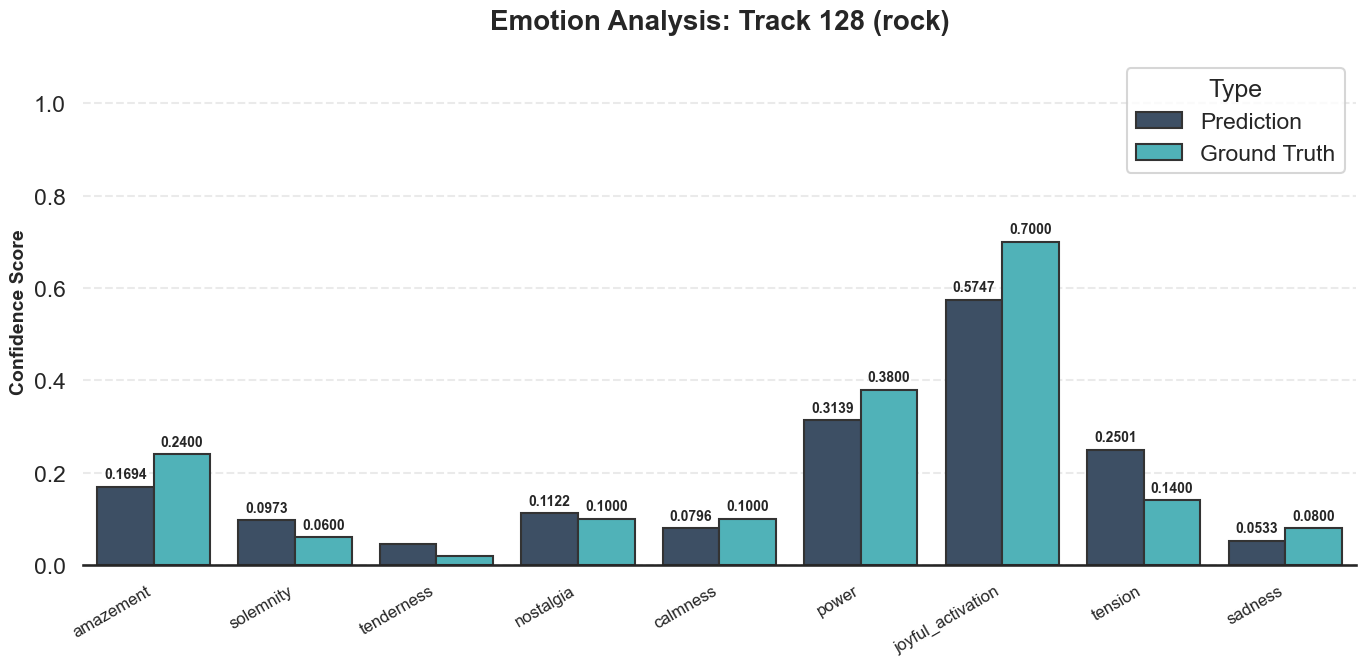



COMPARISON REPORT: Track 128 (rock)

          Emotion  Predicted  Ground Truth   Diff
joyful_activation     0.5747        0.7000 0.1253
            power     0.3139        0.3800 0.0661
          tension     0.2501        0.1400 0.1101
        amazement     0.1694        0.2400 0.0706
        nostalgia     0.1122        0.1000 0.0122
        solemnity     0.0973        0.0600 0.0373
         calmness     0.0796        0.1000 0.0204
          sadness     0.0533        0.0800 0.0267
       tenderness     0.0462        0.0200 0.0262



In [66]:
# Load metadata
df = pd.read_csv('data/emotify_dataset/cleaned_metadata_weighted_probabilities.csv')
df.columns = df.columns.str.strip()

# --- PICK A SONG ---
song_idx = 128
row = df.iloc[song_idx]
path = 'data/emotify_dataset/' + row['songs_path']
genre_tag = row['songs_path'].split('/')[0]
title = f"Track {song_idx} ({genre_tag})"
print(f"🎵 Analyzing Audio Source: {path}..." + "\n\n")

# Get Ground Truth Dictionary
existing_emotion_cols = [emo for emo in EMOTIONS if emo in df.columns]
ground_truth_dict = row[existing_emotion_cols].to_dict()

# RUN DEMO WITH BEAUTIFIED PLOT
_ = predict_and_plot(path, title, ground_truth=ground_truth_dict)

print("\n\n" + "="*50)
print(f"COMPARISON REPORT: {title}")
print("="*50 + "\n")

# Create a clean comparison table
comparison_df = pd.DataFrame({
    'Emotion': EMOTIONS,
    'Predicted': _, 
    'Ground Truth': [ground_truth_dict.get(e, 0.0) for e in EMOTIONS]
})

# Add a 'Diff' column to show error
comparison_df['Diff'] = abs(comparison_df['Predicted'] - comparison_df['Ground Truth'])

comparison_df = comparison_df.sort_values(by='Predicted', ascending=False)

pd.set_option('display.float_format', '{:.4f}'.format)
print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Defination:

## Joyful_activation: 
This is your standard "Happy" or "Upbeat." Think of dance music, pop, or energetic rock. If this bar is high, the song feels energetic and positive.

## Power: 
This represents intensity and dominance. High "Power" usually means the song is loud, heavy, or epic (like Heavy Metal, dramatic Orchestral music, or Hard Rock).

## Tension: 
This implies suspense, unease, or stress. High "Tension" is common in horror movie soundtracks, dissonant music, or aggressive tracks that don't resolve peacefully.

## Sadness: 
Standard melancholy or sorrow. Slow tempos and minor keys usually trigger this.

## Tenderness: 
This is "soft" or "gentle." Think of a lullaby, a soft acoustic guitar track, or a love ballad. It often appears alongside "Calmness."

## Calmness: 
Peaceful and relaxing. Ambient music, meditation tracks, or soft classical music will score high here.

## Nostalgia: 
A sentimental longing for the past. This is often a mix of happy and sad (bittersweet).

## Solemnity: 
Serious, dignified, and heavy. Think of a church organ, a slow national anthem, or a funeral march. It isn't necessarily "sad," but it is very serious.

## Amazement: 
A feeling of wonder or awe. This often happens in complex, sweeping orchestral scores (like a movie soundtrack when a new world is revealed).

Found 1 external songs. Starting analysis...

🎵 Processing: bollywood1.mp3...
🎵 Analyzing: bollywood1.mp3...


[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


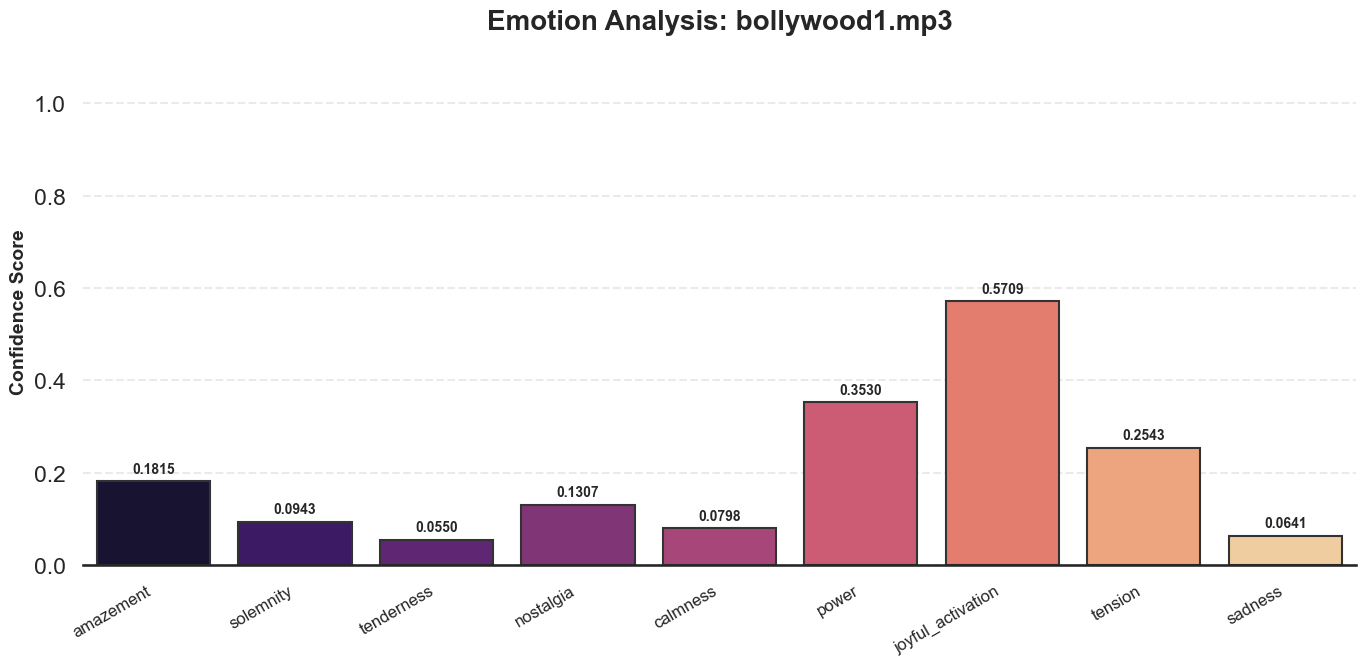

In [48]:
import os

# Define the path to your test folder
test_folder = 'data/emotify_dataset/test_songs/bollywood'

# Check if the folder exists and find files
if os.path.exists(test_folder):
    # List all files that look like audio 
    audio_extensions = ('.mp3', '.wav', '.flac', '.m4a')
    test_files = [f for f in os.listdir(test_folder) if f.lower().endswith(audio_extensions)]

    if len(test_files) == 0:
        print(f"No audio files found in: {test_folder}")
        print("Please drag and drop some .mp3 or .wav files into that folder using the file browser on the left.")
    else:
        print(f"Found {len(test_files)} external songs. Starting analysis...\n")
        
        # 3. Iterate through each file and predict
        for file_name in test_files:
            file_path = os.path.join(test_folder, file_name)
            
            print(f"🎵 Processing: {file_name}...")
            
            # Call your existing function. 
            # We assume ground_truth is None for external data.
            try:
                predict_and_plot(file_path, song_title=file_name, ground_truth=None)
            except Exception as e:
                print(f"Error analyzing {file_name}: {e}")
                
else:
    print(f"Directory not found: {test_folder}")
    print("Please check that you created the folder correctly.")